<a href="https://colab.research.google.com/github/NazarenoSiciliano/Data-Science-II/blob/main/1er%20entrega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Data Science: Análisis de Cobertura de Vacunación (SRP) y Riesgo Epidemiológico en la Provincia de Buenos Aires

## Abstracto y Motivación
El sarampión es una enfermedad viral altamente contagiosa que puede resurgir rápidamente si las tasas de vacunación poblacional disminuyen. Para prevenir brotes y mantener la conocida "inmunidad de rebaño", la Organización Mundial de la Salud (OMS) establece que la cobertura de la vacuna Triple Viral (SRP - Sarampión, Rubéola y Paperas) debe mantenerse de forma sostenida por encima del 95%.

La motivación principal de este proyecto es analizar la evolución histórica (período 2009-2018) de la cobertura de vacunación de la primera y segunda dosis en la Provincia de Buenos Aires. Al identificar patrones, tendencias a la baja y brechas entre las dosis aplicadas, el objetivo final es sentar las bases para entrenar modelos de Machine Learning capaces de predecir o alertar sobre zonas y períodos de alto riesgo epidemiológico ante la posible aparición de un caso índice.

## Audiencia
Este análisis está dirigido a:
* **Ministerio de Salud y Secretarías de Salud Municipales:** Para optimizar la toma de decisiones en políticas públicas y asignación de recursos.
* **Equipos de Vigilancia Epidemiológica:** Para focalizar y dirigir campañas de vacunación territoriales en los años o regiones donde se detecte una baja adherencia al calendario de vacunación, previniendo así futuros brotes.

## ❓ Preguntas e Hipótesis a Responder

El presente análisis busca responder las siguientes interrogantes clave sobre la situación inmunológica de la Provincia de Buenos Aires respecto al sarampión:

1. **Cumplimiento del umbral de seguridad (Hipótesis de riesgo):** * *Pregunta:* ¿Logró la Provincia de Buenos Aires mantener el umbral mínimo del 95% de cobertura en la vacuna Triple Viral (SRP) recomendado por la OMS durante el período 2009-2018?
   * *Hipótesis:* Suponemos que existen múltiples años donde la cobertura perforó el piso del 95%, generando ventanas de vulnerabilidad epidemiológica (bolsas de susceptibles).

2. **Adherencia al calendario de vacunación (Brecha entre dosis):**
   * *Pregunta:* ¿Existe una caída significativa en el porcentaje de aplicación entre la primera dosis (a los 12 meses de edad) y la segunda dosis (al ingreso escolar)?
   * *Hipótesis:* Se espera observar una menor cobertura en la segunda dosis debido a la falta de seguimiento o barreras de acceso al sistema de salud a medida que el niño crece.

3. **Detección de períodos críticos (Análisis temporal):**
   * *Pregunta:* ¿Cuáles fueron los años de mayor riesgo epidemiológico debido a las bajas tasas de inmunización general?
   * *Hipótesis:* Los años con caídas abruptas en la vacunación preceden estadísticamente a los brotes de enfermedades inmunoprevenibles.

4. **Proyección y Modelado (Visión a futuro para Machine Learning):**
   * *Pregunta:* ¿Es posible predecir tendencias de baja cobertura en años futuros analizando el comportamiento histórico de estas dos dosis?
   * *Hipótesis:* Entrenando un modelo de Machine Learning con el historial de coberturas y variables temporales, podremos alertar de forma temprana sobre futuras caídas en la vacunación.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_vacunas = pd.read_csv('/content/dicei-vacunas-srp-2009-2018.csv')

print("Dimensiones del dataset:", df_vacunas.shape)
display(df_vacunas.head())

Dimensiones del dataset: (24, 22)


,jurisdiccion_id,jurisdiccion_nombre,2009_cob_ 1_ dosis_12_meses,2009_cob_ 2_ dosis_ingreso_escolar,2010_cob_ 1_ dosis_12_meses,2010_cob_ 2_ dosis_ingreso_escolar,2011_cob_ 1_ dosis_12_meses,2011_cob_ 2_ dosis_ingreso_escolar,2012_cob_ 1_ dosis_12_meses,2012_cob_ 2_ dosis_ingreso_escolar,...,2014_cob_ 1_ dosis_al_12_meses,2014_cob_ 2_ dosis_ingreso_escolar,2015_cob_ 1_ dosis_12_meses,2015_cob_ 2_ dosis_ingreso_escolar,2016_cob_ 1_ dosis_12_meses,2016_cob_ 2_ dosis_ingreso_escolar,2017_cob_ 1_ dosis_12_meses,2017_cob_ 2_ dosis_ingreso_escolar,2018_cob_ 1_ dosis_12_meses,2018_cob_ 2_ dosis_ingreso_escolar
0,6,BUENOS AIRES,105.4,98.8,108.6,105.2,93.0,94.1,89.9,90.1,...,97.7,101.0,85.2,85.5,90.9,88.5,91.5,89.9,99.2,99.4
1,2,CABA,95.0,95.3,96.5,90.1,91.6,103.0,92.6,91.5,...,83.8,86.8,73.6,70.5,83.5,76.1,81.7,80.8,97.7,99.7
2,10,CATAMARCA,112.7,95.6,93.8,92.7,82.7,74.2,85.5,78.8,...,89.9,96.6,98.4,84.5,95.0,85.2,90.3,89.7,96.0,110.8
3,22,CHACO,107.1,87.4,100.7,106.6,104.4,89.4,94.0,89.0,...,99.2,85.6,100.3,83.1,91.1,76.7,97.9,112.6,95.3,92.6
4,26,CHUBUT,92.6,106.1,93.7,66.4,101.1,98.1,98.4,90.7,...,103.2,102.2,98.1,109.4,96.0,99.7,94.6,95.0,99.1,101.8


El dataset original tiene los años como columnas (formato wide). Para graficar y analizar, necesitamos transformarlo (formato long). Vamos a enfocarnos en la Provincia de Buenos Aires.

In [3]:

df_pba = df_vacunas[df_vacunas['jurisdiccion_nombre'] == 'BUENOS AIRES'].copy()

df_pba_melted = df_pba.melt(id_vars=['jurisdiccion_id', 'jurisdiccion_nombre'],
                            var_name='anio_dosis',
                            value_name='cobertura_pct')


df_pba_melted['anio'] = df_pba_melted['anio_dosis'].str.split('_').str[0].astype(int)

def clasificar_dosis(texto):
    if '1_ dosis' in texto:
        return '1ra Dosis (12 meses)'
    else:
        return '2da Dosis (Ingreso Escolar)'

df_pba_melted['tipo_dosis'] = df_pba_melted['anio_dosis'].apply(clasificar_dosis)

df_pba_clean = df_pba_melted[['jurisdiccion_nombre', 'anio', 'tipo_dosis', 'cobertura_pct']]

print("Datos limpios y transformados:")
display(df_pba_clean.head())

Datos limpios y transformados:


,jurisdiccion_nombre,anio,tipo_dosis,cobertura_pct
0,BUENOS AIRES,2009,1ra Dosis (12 meses),105.4
1,BUENOS AIRES,2009,2da Dosis (Ingreso Escolar),98.8
2,BUENOS AIRES,2010,1ra Dosis (12 meses),108.6
3,BUENOS AIRES,2010,2da Dosis (Ingreso Escolar),105.2
4,BUENOS AIRES,2011,1ra Dosis (12 meses),93.0


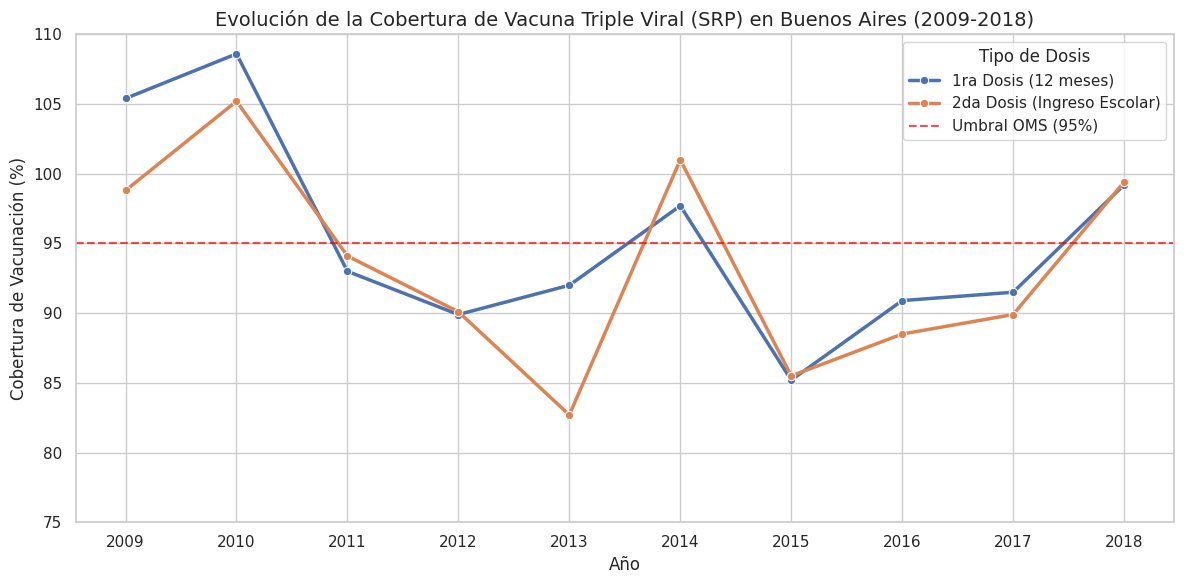

Insight: El punto más bajo de cobertura se registró en el año 2013 con un 82.7%.


In [4]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_pba_clean, x='anio', y='cobertura_pct', hue='tipo_dosis', marker='o', linewidth=2.5)

plt.axhline(95, color='red', linestyle='--', alpha=0.7, label='Umbral OMS (95%)')

plt.title('Evolución de la Cobertura de Vacuna Triple Viral (SRP) en Buenos Aires (2009-2018)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cobertura de Vacunación (%)', fontsize=12)
plt.xticks(df_pba_clean['anio'].unique())
plt.legend(title='Tipo de Dosis')
plt.ylim(75, 110)

plt.savefig('evolucion_vacunacion_pba.png', dpi=300)
plt.show()

min_cobertura = df_pba_clean['cobertura_pct'].min()
anio_min_cob = df_pba_clean.loc[df_pba_clean['cobertura_pct'].idxmin(), 'anio']
print(f"Insight: El punto más bajo de cobertura se registró en el año {anio_min_cob} con un {min_cobertura}%.")